#  Rule Based Model

### Import libraries

In [ ]:
#Import libraries
import os
from google.colab import drive
drive.mount('/content/drive')

import ast
from bs4 import BeautifulSoup
import chardet
from collections import Counter
from collections import defaultdict

!pip install google-play-scraper
from google_play_scraper import search, permissions, app

from itertools import chain
import joblib #save models
import json
import logging
import matplotlib.pyplot as plt
import numpy as np
import openpyxl
from openpyxl import Workbook
from openpyxl.utils.dataframe import dataframe_to_rows
import pandas as pd
from pathlib import Path
import pickle #save jobs
import random
import re
import shutil
import sys
import time
from tqdm import tqdm  # Import tqdm for the progress bar
from tqdm.auto import tqdm
tqdm.pandas()

!pip install nltk
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

import warnings
warnings.filterwarnings("ignore")
from wordcloud import WordCloud

import seaborn as sns
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.utils.class_weight import compute_class_weight

!pip install joblib scikit-learn nltk --quiet
!pip install transformers datasets scikit-learn tqdm joblib --quiet
import torch
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from transformers import BertTokenizerFast, BertForSequenceClassification
from transformers import logging as transformers_logging


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.7 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


### Preprocessing

In [ ]:
#Load MPP 270 dataset
df_mpp = pd.read_excel('MPP-270_ Annotated App Policy Corpus.xlsx')
df_mpp.head(2)

,APP_ID,CAMERA,MICROPHONE,PHONE_CALL,SENSOR,SMS,CALENDAR,CONTACTS,LOCATION,STORAGE,PERSISTENTID,Unnamed: 11,Unnamed: 12
0,at.ner.lepsWorld2,0,0,0,0,0,0,0,"We will only collect such information if (a) ""...",0,['We collect device specific information when ...,NaN,NaN
1,cn.xender,NOT_FOUND,0,NOT_FOUND,0,NOT_FOUND,0,"""Except in the circumstances of this paragraph...",Personal Information includes your geographic ...,NOT_FOUND,"[""Personal Information includes your geographi...",NaN,NaN


In [ ]:
# MPP 270 dataset info
df_mpp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379 entries, 0 to 378
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   APP_ID        270 non-null    object 
 1   CAMERA        270 non-null    object 
 2   MICROPHONE    270 non-null    object 
 3   PHONE_CALL    270 non-null    object 
 4   SENSOR        270 non-null    object 
 5   SMS           270 non-null    object 
 6   CALENDAR      270 non-null    object 
 7   CONTACTS      270 non-null    object 
 8   LOCATION      270 non-null    object 
 9   STORAGE       270 non-null    object 
 10  PERSISTENTID  271 non-null    object 
 11  Unnamed: 11   0 non-null      float64
 12  Unnamed: 12   1 non-null      object 
dtypes: float64(1), object(12)
memory usage: 38.6+ KB


In [ ]:
# Drop noisy columns
df_mpp = df_mpp.drop(columns=["Unnamed: 11", "Unnamed: 12"])

# Ensure only rows where app id is present is used
df_mpp = df_mpp[df_mpp['APP_ID'].notnull()]

# All data type changed to string
df_mpp = df_mpp.astype(str)

#confirm columns
df_mpp.columns

Index(['APP_ID', 'CAMERA', 'MICROPHONE', 'PHONE_CALL', 'SENSOR', 'SMS',
       'CALENDAR', 'CONTACTS', 'LOCATION', 'STORAGE', 'PERSISTENTID'],
      dtype='object')

In [ ]:
# Create a new column for App Names and other metadata using google app scrapper
def fetch_info(app_id):
    try:
        info = app(app_id)
        perm = permissions(app_id)
        return info["title"], info["icon"], info["genreId"], info["contentRating"],info['privacyPolicy'],perm
    except:
        return None, None, None, None,None,None

df_mpp[["App Name", "Icon URL", "Category", "Age Group", "Policy Link","Perm"]] = df_mpp["APP_ID"].progress_apply(lambda x: pd.Series(fetch_info(x)))


# show a preview
print(df_mpp[["APP_ID", "App Name", "Icon URL", "Category", "Age Group","Policy Link","Perm"]].head(3))

print(" ")

# show info
print(df_mpp[["APP_ID", "App Name", "Icon URL", "Category", "Age Group","Policy Link","Perm"]].info())

  0%|          | 0/270 [00:00<?, ?it/s]

                             APP_ID                       App Name  \
0                 at.ner.lepsWorld2                  Lep's World 2   
1                         cn.xender  Xender - Share Music Transfer   
2  com.FDGEntertainment.redball4.gp                     Red Ball 4   

                                            Icon URL     Category Age Group  \
0  https://play-lh.googleusercontent.com/MAtrWn_z...  GAME_ARCADE      Teen   
1  https://play-lh.googleusercontent.com/y-jJBrUk...        TOOLS  Everyone   
2  https://play-lh.googleusercontent.com/_2RsmTzf...  GAME_ARCADE  Everyone   

                                         Policy Link  \
0              https://www.nerbyte.com/privacypolicy   
1                  https://www.xender.com/terms.html   
2  http://www.fdg-entertainment.com/en/privacy-po...   

                                                Perm  
0  {'Wi-Fi connection information': ['view Wi-Fi ...  
1  {'Location': ['approximate location (network-b...  
2  {'Phone':

In [ ]:
df_mpp_null = df_mpp[df_mpp['App Name'].isnull()]
df_mpp_null.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 15 to 257
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   APP_ID        30 non-null     object
 1   CAMERA        30 non-null     object
 2   MICROPHONE    30 non-null     object
 3   PHONE_CALL    30 non-null     object
 4   SENSOR        30 non-null     object
 5   SMS           30 non-null     object
 6   CALENDAR      30 non-null     object
 7   CONTACTS      30 non-null     object
 8   LOCATION      30 non-null     object
 9   STORAGE       30 non-null     object
 10  PERSISTENTID  30 non-null     object
 11  App Name      0 non-null      object
 12  Icon URL      0 non-null      object
 13  Category      0 non-null      object
 14  Age Group     0 non-null      object
 15  Policy Link   0 non-null      object
 16  Perm          0 non-null      object
dtypes: object(17)
memory usage: 4.2+ KB


In [ ]:
# A fallback where null
df_mpp["App Name"] = df_mpp["App Name"].fillna(
    df_mpp["APP_ID"].apply(lambda x: x.split(".")[-1].capitalize() if isinstance(x, str) else "Unknown"))
df_mpp["Icon URL"] = df_mpp["Icon URL"].fillna("https://www.svgrepo.com/svg/533118/mobile-bolt.svg")
df_mpp["Category"] = df_mpp["Category"].fillna("Not Available")
df_mpp["Age Group"] = df_mpp["Age Group"].fillna("Not Available")
df_mpp["Policy Link"] = df_mpp["Policy Link"].fillna("Not Available")
df_mpp["Perm"] = df_mpp["Perm"].fillna("Not Available")

print(df_mpp[["APP_ID", "App Name", "Icon URL", "Category", "Age Group","Policy Link","Perm"]].info())

<class 'pandas.core.frame.DataFrame'>
Index: 270 entries, 0 to 269
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   APP_ID       270 non-null    object
 1   App Name     270 non-null    object
 2   Icon URL     270 non-null    object
 3   Category     270 non-null    object
 4   Age Group    270 non-null    object
 5   Policy Link  270 non-null    object
 6   Perm         270 non-null    object
dtypes: object(7)
memory usage: 16.9+ KB
None


In [ ]:
df_mpp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 270 entries, 0 to 269
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   APP_ID        270 non-null    object
 1   CAMERA        270 non-null    object
 2   MICROPHONE    270 non-null    object
 3   PHONE_CALL    270 non-null    object
 4   SENSOR        270 non-null    object
 5   SMS           270 non-null    object
 6   CALENDAR      270 non-null    object
 7   CONTACTS      270 non-null    object
 8   LOCATION      270 non-null    object
 9   STORAGE       270 non-null    object
 10  PERSISTENTID  270 non-null    object
 11  App Name      270 non-null    object
 12  Icon URL      270 non-null    object
 13  Category      270 non-null    object
 14  Age Group     270 non-null    object
 15  Policy Link   270 non-null    object
 16  Perm          270 non-null    object
dtypes: object(17)
memory usage: 38.0+ KB


In [ ]:
#SAVE A COPY
mpp2 = df_mpp.copy()

In [ ]:
perm_label = [
    "CAMERA", "MICROPHONE", "PHONE_CALL", "SENSOR", "SMS",
    "CALENDAR", "CONTACTS", "LOCATION", "STORAGE", "PERSISTENTID"
]

# Combining all policy texts into one cell for each app
def merge_permission_texts(row):
    all_texts = []
    for col in perm_label:
        data = row.get(col)

        # Skip if value is invalid
        if data in [0, "0", "NOT_FOUND", "", None]:
            continue

        # Handle valid list of texts
        if isinstance(data, list):
            valid_items = [item for item in data if item not in [None, "", "0", "NOT_FOUND"]]
            all_texts.extend(valid_items)

        elif isinstance(data, str) and data not in ["0", "NOT_FOUND", ""]:
            all_texts.append(data)

    return " ".join(all_texts).strip()

df_mpp['MergedPolicyText'] = df_mpp.apply(merge_permission_texts, axis=1)

df_mpp[['APP_ID', 'MergedPolicyText']].head()


,APP_ID,MergedPolicyText
0,at.ner.lepsWorld2,"We will only collect such information if (a) ""..."
1,cn.xender,"""Except in the circumstances of this paragraph..."
2,com.FDGEntertainment.redball4.gp,The advertisers may collect and use informatio...
3,com.UCMobile.intl,"Information including device type and model, n..."
4,com.activision.callofduty.shooter,"[""Commercial Information, e.g., delivery infor..."


In [ ]:
# Combine all requested permissiosn
df_mpp['Permissions Used'] = df_mpp.apply(lambda row: [perm for perm in perm_label if row.get(perm) != '0'], axis=1)
df_mpp[['APP_ID', 'Permissions Used','Perm']].head()

,APP_ID,Permissions Used,Perm
0,at.ner.lepsWorld2,"[LOCATION, PERSISTENTID]",{'Wi-Fi connection information': ['view Wi-Fi ...
1,cn.xender,"[CAMERA, PHONE_CALL, SMS, CONTACTS, LOCATION, ...",{'Location': ['approximate location (network-b...
2,com.FDGEntertainment.redball4.gp,"[LOCATION, STORAGE, PERSISTENTID]","{'Phone': ['read phone status and identity'], ..."
3,com.UCMobile.intl,"[CAMERA, CONTACTS, LOCATION, STORAGE, PERSISTE...",{'Device & app history': ['read your Web bookm...
4,com.activision.callofduty.shooter,"[MICROPHONE, LOCATION, STORAGE, PERSISTENTID]",{'Calendar': ['add or modify calendar events a...


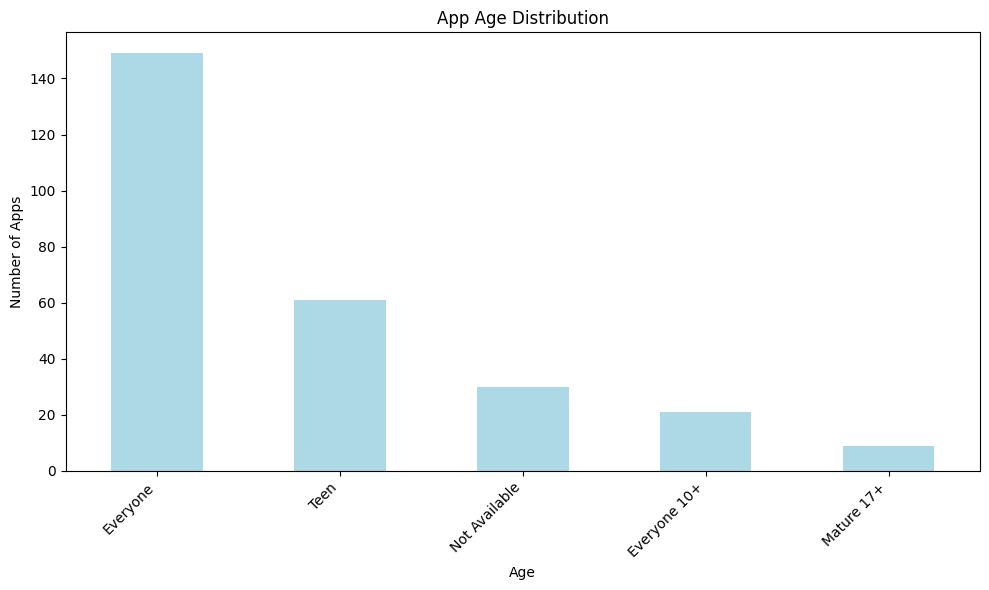

In [ ]:
# Age Distribution
age_counts = df_mpp['Age Group'].value_counts()

# Plot bar chart
plt.figure(figsize=(10, 6))
age_counts.plot(kind='bar', color='lightblue')

plt.title('App Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Apps')
plt.xticks(rotation=45, ha='right')  # Rotate x labels for readability
plt.tight_layout()
plt.show()

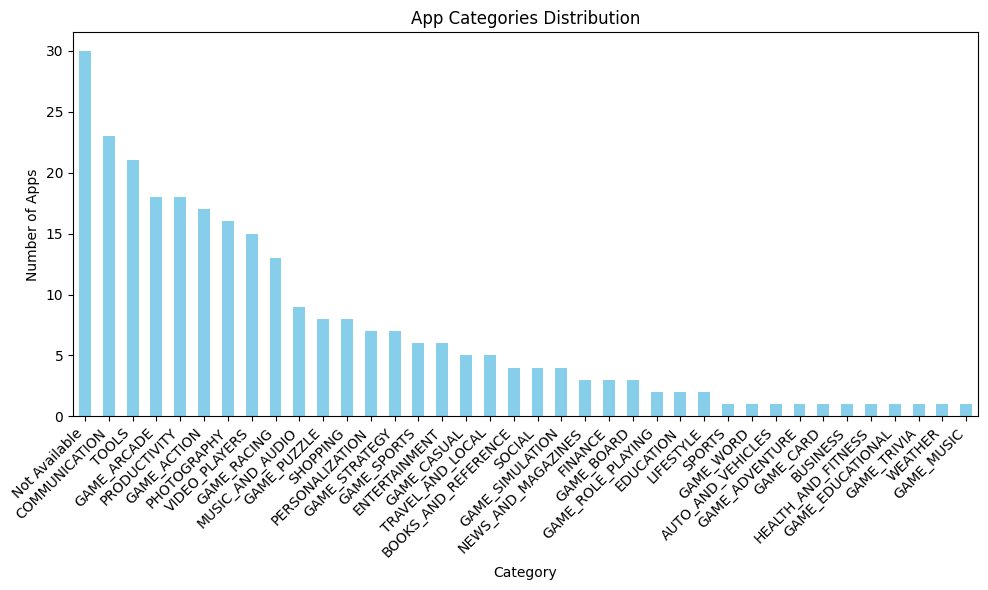

In [ ]:
# Count category occurrences
category_counts = df_mpp['Category'].value_counts()

# Plot bar chart
plt.figure(figsize=(10, 6))
category_counts.plot(kind='bar', color='skyblue')

plt.title('App Categories Distribution')
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.xticks(rotation=45, ha='right')  # Rotate x labels for readability
plt.tight_layout()
plt.show()


In [ ]:
df_mpp.to_excel('cleaned_MPP270_permissions.xlsx', index=False)
df_mpp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 270 entries, 0 to 269
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   APP_ID            270 non-null    object
 1   CAMERA            270 non-null    object
 2   MICROPHONE        270 non-null    object
 3   PHONE_CALL        270 non-null    object
 4   SENSOR            270 non-null    object
 5   SMS               270 non-null    object
 6   CALENDAR          270 non-null    object
 7   CONTACTS          270 non-null    object
 8   LOCATION          270 non-null    object
 9   STORAGE           270 non-null    object
 10  PERSISTENTID      270 non-null    object
 11  App Name          270 non-null    object
 12  Icon URL          270 non-null    object
 13  Category          270 non-null    object
 14  Age Group         270 non-null    object
 15  Policy Link       270 non-null    object
 16  Perm              270 non-null    object
 17  MergedPolicyText  270

### Permission Keyword Corpus

- Here we use TF-IDF and topic modeling (LDA) for unsupervised keyword extraction.

- We use stopword removal, lemmatization, and manual filtering to improve keyword quality.

- We then use manual seeding and word cloud visualization to ensure domain relevance.

- Finally, apply rule-based matching to link permissions requested by apps with policy explanations.

In [ ]:
# Build per-permission corpus
dfp = df_mpp.copy()
perm_label = ['CAMERA', 'MICROPHONE', 'PHONE_CALL', 'SENSOR', 'SMS',
              'CALENDAR', 'CONTACTS', 'LOCATION', 'STORAGE', 'PERSISTENTID']

rows = []
for perm in perm_label:
    # Keep rows with valid policy text for this permission
    subset = dfp[dfp[perm].apply(lambda x: isinstance(x, str) and x not in ["0", "NOT_FOUND"])].copy()
    subset['label'] = perm              # Set permission as label
    subset['text'] = subset[perm]      # Set permission text as the feature
    rows.append(subset[['text', 'label']])

df_perm = pd.concat(rows).reset_index(drop=True)

#  overview
df_perm['label'].value_counts()


,count
label,
PERSISTENTID,253
LOCATION,209
STORAGE,133
CAMERA,78
MICROPHONE,57
CONTACTS,45
PHONE_CALL,27
SMS,8
SENSOR,6


In [ ]:
#Preprocess and TF-IDF
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Lowercase
    text = text.lower()
    # Remove non-alphabetic characters
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    cleaned_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 1
    ]

    return " ".join(cleaned_tokens)


# Group text by permission label into a dictionary
perm_corpora = {
    label: group['text'].tolist()
    for label, group in df_perm.groupby('label')
}

# get keywords

perm_keywords = {}

for perm, texts in perm_corpora.items():
    clean_texts = [clean_text(t) for t in texts]
    vectorizer = TfidfVectorizer(ngram_range=(1, 3), stop_words='english')
    X = vectorizer.fit_transform(clean_texts)

    sums = X.sum(axis=0).A1
    terms = vectorizer.get_feature_names_out()
    top_n = 20
    top_words = [terms[i] for i in sums.argsort()[::-1][:top_n]]
    perm_keywords[perm] = top_words
    print(f"{perm}: {top_words}")


CALENDAR: ['information', 'calendar', 'use information', 'use information calendar', 'information calendar', 'use', 'contact', 'service', 'setting', 'mobile phone', 'phone', 'mobile', 'search', 'application', 'data', 'including', 'address book', 'book', 'address', 'book calendar']
CAMERA: ['photo', 'camera', 'service', 'information', 'image', 'like', 'appear', 'google', 'data', 'video', 'device', 'use', 'activity', 'phone', 'provide', 'service like', 'photo appear activity', 'photo appear', 'appear activity', 'profile']
CONTACTS: ['service', 'upload contact', 'contact', 'information', 'upload', 'social', 'medium', 'social medium', 'content', 'account', 'content service', 'skype', 'list', 'example', 'purpose', 'friend', 'user', 'cooky', 'use', 'contact list']
LOCATION: ['location', 'device', 'information', 'service', 'data', 'use', 'google', 'address', 'collect', 'ip', 'like', 'ip address', 'access', 'number', 'setting', 'sensor', 'location information', 'including', 'example', 'identif

In [ ]:
# Vectorize
vectorizer = TfidfVectorizer(ngram_range=(1, 3), stop_words='english')
X = vectorizer.fit_transform(clean_texts)

# Fit LDA
lda = LatentDirichletAllocation(n_components=3, random_state=0)
lda.fit(X)

# Get the feature names
terms = vectorizer.get_feature_names_out()

# Extract top topic words per topic
topic_keywords = set()

for idx, topic in enumerate(lda.components_):
    top_terms = [terms[i] for i in topic.argsort()[:-10 - 1:-1]]
    print(f"Topic {idx}: {top_terms}")
    topic_keywords.update(top_terms)

# show final keyword set
print("\nAll topic model words:", sorted(topic_keywords))


Topic 0: ['profile', 'camera', 'picture', 'profile picture', 'data', 'access', 'service', 'user', 'photo', 'permission']
Topic 1: ['information', 'profile', 'device', 'profile information', 'photo', 'stored', 'location', 'image', 'information profile photo', 'profile information profile']
Topic 2: ['create', 'upload', 'photo', 'content', 'photo video', 'create upload receive', 'content create', 'content create upload', 'create upload', 'upload receive']

All topic model words: ['access', 'camera', 'content', 'content create', 'content create upload', 'create', 'create upload', 'create upload receive', 'data', 'device', 'image', 'information', 'information profile photo', 'location', 'permission', 'photo', 'photo video', 'picture', 'profile', 'profile information', 'profile information profile', 'profile picture', 'service', 'stored', 'upload', 'upload receive', 'user']



===== CAMERA =====
Top 10 TF-IDF words:
photo: 26.1446
information: 21.0988
service: 18.8562
camera: 18.6921
image: 16.3772
name: 15.8204
video: 13.6059
device: 13.2014
data: 12.0236
use: 11.7263


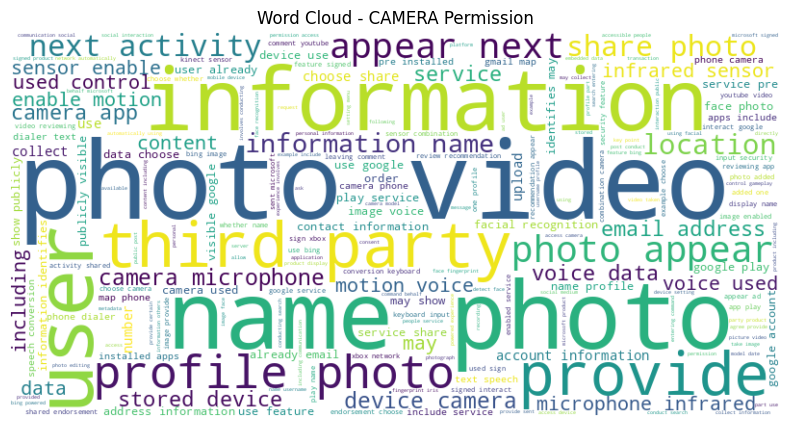


===== MICROPHONE =====
Top 10 TF-IDF words:
audio: 20.0770
information: 18.1000
voice: 12.9561
video: 11.0891
service: 9.9034
content: 9.0760
device: 8.8106
microphone: 8.1914
feature: 8.1412
text: 5.1462


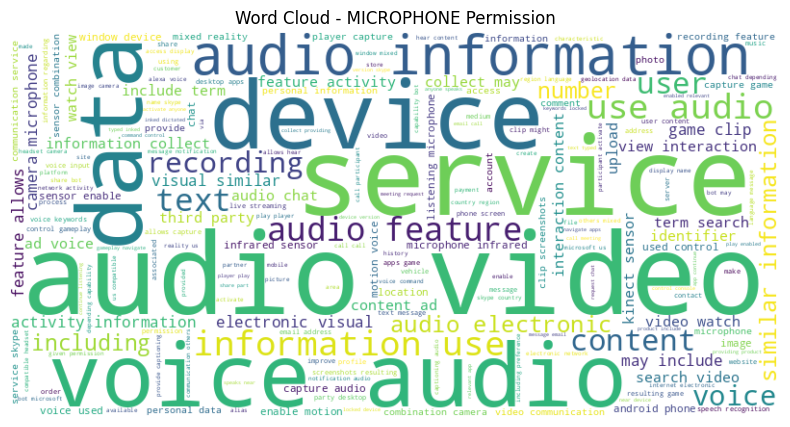


===== PHONE_CALL =====
Top 10 TF-IDF words:
information: 10.8181
number: 9.3511
call: 8.3732
phone: 7.1248
device: 6.4163
message: 5.3594
identifier: 5.0198
collect: 4.1974
type: 3.9174
name: 3.5883


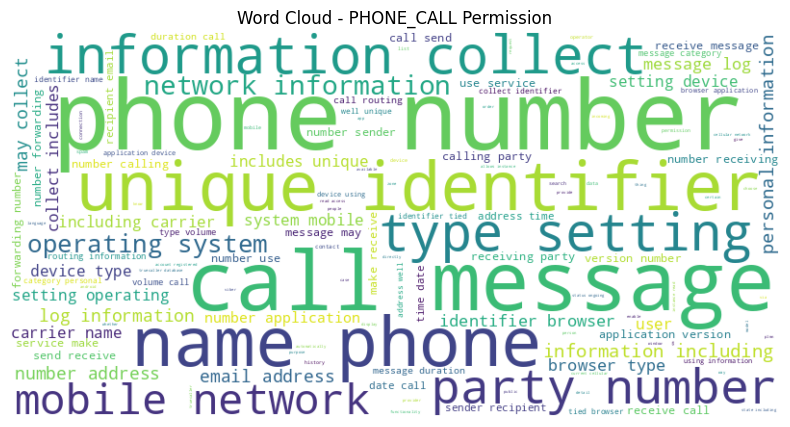


===== SENSOR =====
Top 10 TF-IDF words:
location: 2.3275
device: 2.0327
service: 1.7690
use: 1.5562
information: 1.5084
google: 1.4861
accelerometer: 1.2523
sensor: 1.1755
like: 1.1146
thing: 0.7430


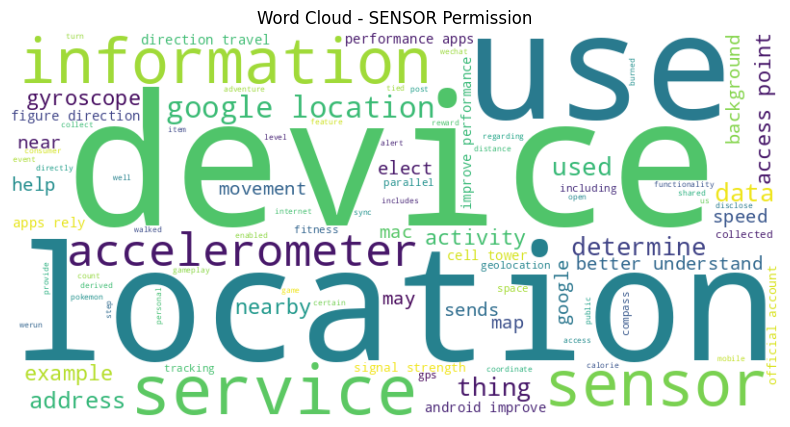


===== SMS =====
Top 10 TF-IDF words:
call: 3.8179
message: 3.7338
number: 3.3153
information: 1.7494
party: 1.6215
receive: 1.6215
log: 1.4303
may: 1.1015
use: 1.1015
collect: 1.0918


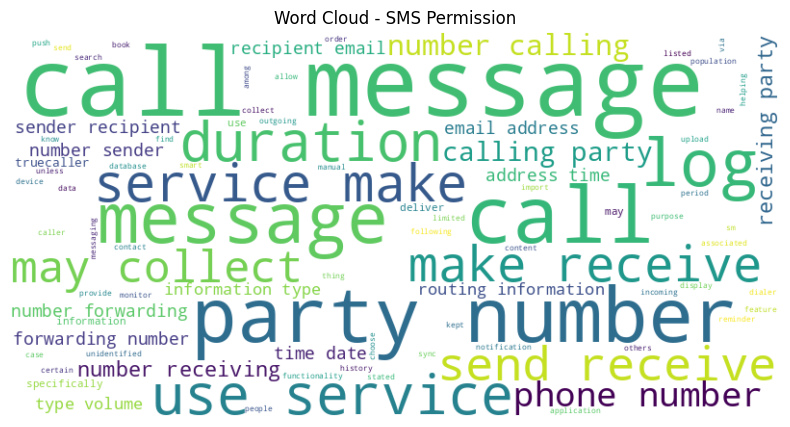


===== CALENDAR =====
Top 10 TF-IDF words:
information: 1.8566
calendar: 1.2348
contact: 0.7555
book: 0.3398
data: 0.3398
including: 0.3398
setting: 0.3293
application: 0.2470
phone: 0.2470
search: 0.2470


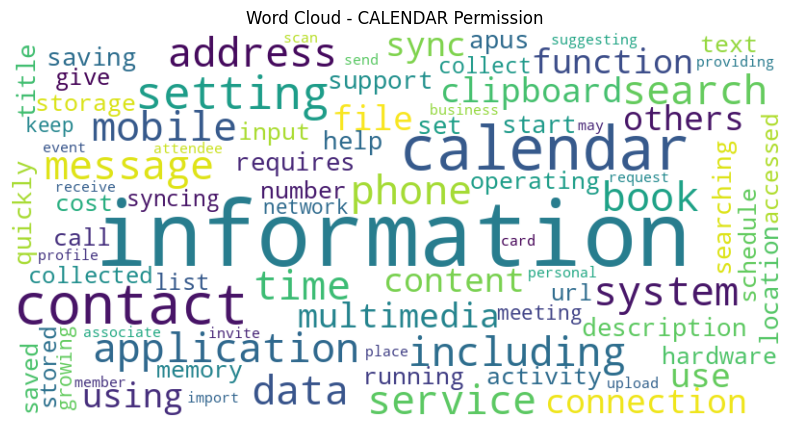


===== CONTACTS =====
Top 10 TF-IDF words:
contact: 17.7966
information: 13.5642
service: 11.9563
social: 9.3144
medium: 8.7557
content: 5.4248
account: 4.8506
party: 4.4356
third: 4.4356
use: 3.8088


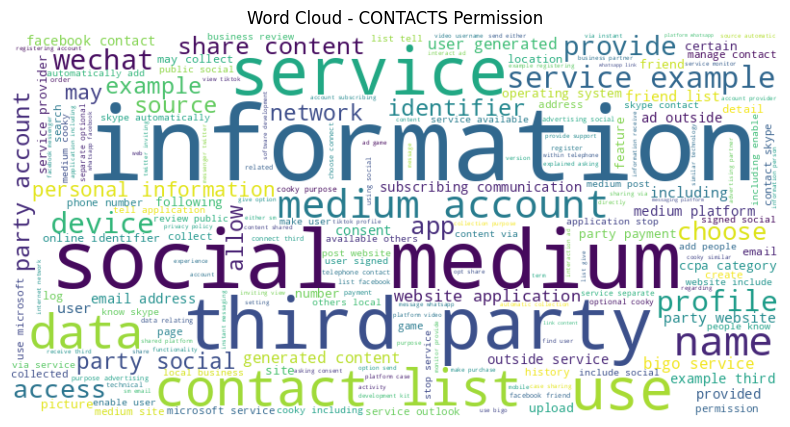


===== LOCATION =====
Top 10 TF-IDF words:
location: 91.6118
information: 79.7015
device: 69.6259
service: 52.2028
data: 45.1174
use: 36.5881
may: 34.6703
address: 33.2372
collect: 27.5641
access: 21.2592


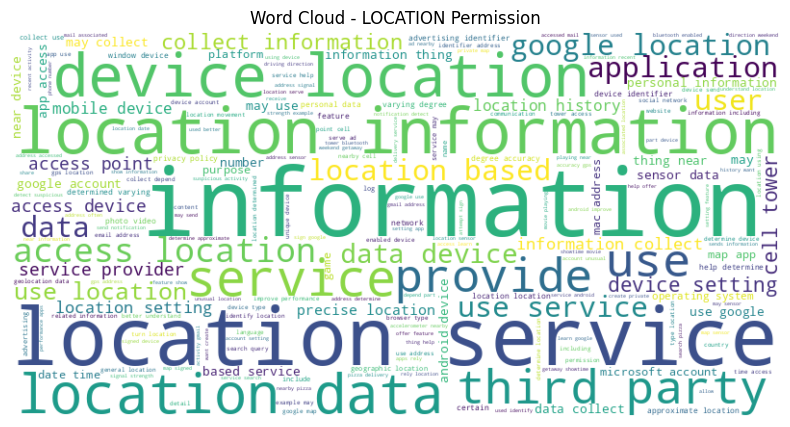


===== STORAGE =====
Top 10 TF-IDF words:
information: 39.0754
upload: 32.3374
photo: 31.8756
content: 26.4158
service: 22.4850
create: 20.1685
video: 18.6903
receive: 14.5748
collect: 12.4824
google: 11.4625


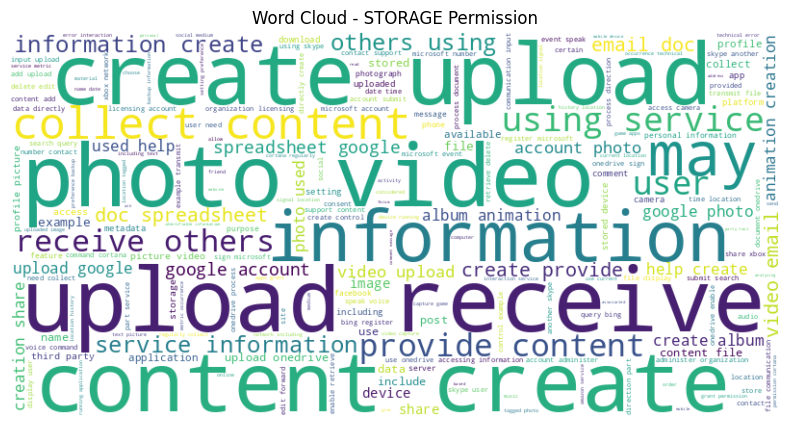


===== PERSISTENTID =====
Top 10 TF-IDF words:
device: 117.5299
information: 80.9516
identifier: 64.4223
address: 51.0720
service: 44.9302
type: 44.5006
number: 44.1769
collect: 40.1147
mobile: 40.0265
browser: 36.7990


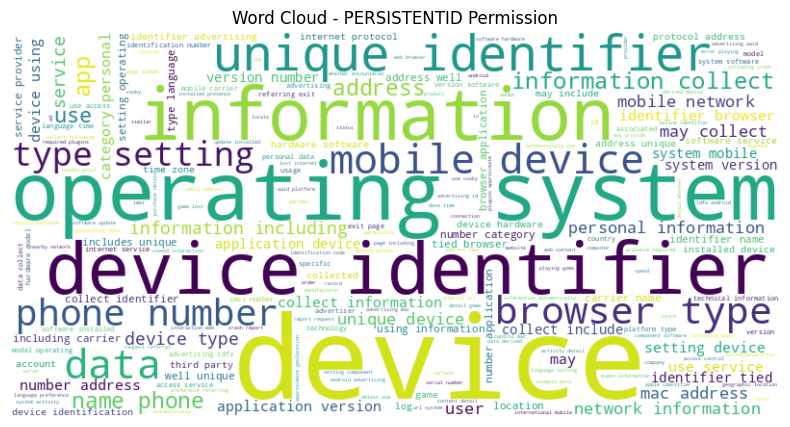

In [ ]:
# Preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'\W+', ' ', text)  # remove special chars
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]
    return ' '.join(tokens)

for permission in perm_label:
    print(f"\n=##== {permission} =##==")

    # Filter out '0' and 'NOT_FOUND'
    permdf = df_mpp[(df_mpp[permission] != '0') & (df_mpp[permission] != 'NOT_FOUND')].copy()

    if permdf.empty:
        print("No valid data to process.")
        continue

    # Preprocess
    permdf[f'{permission}_processed'] = permdf[permission].apply(preprocess)

    # TF-IDF
    tfidf = TfidfVectorizer(max_features=10)
    tfidf_matrix = tfidf.fit_transform(permdf[f'{permission}_processed'])

    # Get top TF-IDF words
    feature_names = tfidf.get_feature_names_out()
    scores = tfidf_matrix.sum(axis=0).A1
    top_words = sorted(zip(feature_names, scores), key=lambda x: x[1], reverse=True)

    print("Top 10 TF-IDF words:")
    for word, score in top_words:
        print(f"{word}: {score:.4f}")

    # Word Cloud
    combined_text = ' '.join(permdf[f'{permission}_processed'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(combined_text)

    # Display Word Cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud - {permission} Permission')
    plt.show()


In [ ]:
# Combine all top words across permissions
all_words = [word for words in perm_keywords.values() for word in words]

# Count frequency
global_freq = Counter(all_words)

# A threshold to remove words that appear in ≥4 permissions
threshold = 4
generic_words = {word for word, count in global_freq.items() if count >= threshold}

# Additional known generic terms to exclude
extra_generic = {"example",'share', "thing", "user", "used", "provide", "feature", "service", "app", "unique","play", "type",'determine','ip',
                 "choose", 'service like',"like","including","appear", "receive",'activity','list', 'medium',"call", 'google location', 'google location service',
                 'application','account','mobile','mobile phone','purpose',"social",'identifier', 'use information','friend', 'id','location service', 'information collect',
                 'information use', 'book', 'use service', 'use service make', 'volume', 'time date', 'voice', 'video','use google', 'use google location','phone number',
                 'log','photo','message','track','browser','file', 'appointment', 'schedule','cooky', 'skype','type volume message','sensor','content service',
                 'audio','electronic','network','search','contact','address time','callingparty', 'callingparty number', 'callingparty number receivingparty'}

# Combine both generic and topic model words into one exclusion set
combined_exclude = generic_words.union(topic_keywords).union(extra_generic)

# Apply combined filtering
filtered_keywords = {
    perm: [w for w in words if w not in combined_exclude]
    for perm, words in perm_keywords.items()
}

#Manual seeds inferring from word cloud as well
manual_seeds = {
    "CAMERA": [
        "camera", "take photo", "take picture", "record video",'photograph', "capture image", "phone camera", 'video call', 'captured photo','face recognition', 'facial recognition',
        "snap", "use camera", "use photo", "video recording", "live video", "access camera", 'captured picture','image information', 'photo'
    ],
    "MICROPHONE": [
        "microphone", "record audio", "voice call", "speak", "audio input", 'audio feature','sound record',
         "voice message", "voice chat","audio chat", "record voice",'audio record','voice', 'audio',
    ],
    "PHONE_CALL": [
          "dial number", "receive call", "make call", "incoming call",'callingparty','call history',
        "outgoing call", "call log",  "phone number", "telephony",'mobile network','phone number'
    ],
    "SENSOR": [
        "sensor", "motion", "accelerometer", "gyroscope", "detect movement", 'track activity',
        "shake", "device tilt", "orientation", "fitness tracking", "step count"
    ],
    "SMS": [
        "sms", "text message", "receive sms", "send sms", "read messages"," receive message", "send message",
        "message log", "verification code", "otp", "short message", "message content"
    ],
    "CALENDAR": [
        "calendar", "calendar information", "schedule appointment", "schedule meeting", "add event",'book appointment',
        "view calendar", "calendar access", "reminder", 'book meeting',
    ],
    "CONTACTS": [
        "access contact", "address book", "contact list","phonebook",'contact information', 'contact',
        "sync contact","read contact", "add friend", "access friend",  "import friend", "connect friend"
    ],
    "LOCATION": [
        "location", "gps", "track location", "where you are", "map", "geolocation", 'location service',
        "current location", "find nearby", "location data", "locate","access location"
    ],
    "STORAGE": [
        "file storage", "save file", "access media", "transmit file","download", "upload", 'share content','photo album','camera roll','stored device',
        "read storage", "write storage", "photo storage", "video file","file communication",'app storage','storing photo', 'media file',
          "usb storage", "external storage",'local storage', 'information stored','app storage', 'store file', 'device storage','access photo medium file'
    ],
    "PERSISTENTID": [
        "device id", 'device number', "android id", "advertising id", "imei", "serial number",'information device','identifier associated device','system version', 'device version',
        "persistent identifier",'device identifier', "unique identifier", "hardware id", "device token", "collect identifier", 'device information', 'identifier device'
    ]
}

# Merge filtered keywords with manual seeds
final_keywords = {
    perm: sorted(set(filtered_keywords.get(perm, []) + manual_seeds.get(perm, [])))
    for perm in set(filtered_keywords.keys()).union(manual_seeds.keys())
}

# Preview
for perm, words in final_keywords.items():
    print(f"{perm}: {words}")

import json
# save keywords
with open("final_keywords.json", "w") as f:
    json.dump(final_keywords, f)

PERSISTENTID: ['advertising id', 'android id', 'collect identifier', 'device id', 'device identifier', 'device information', 'device number', 'device token', 'device version', 'hardware id', 'identifier associated device', 'identifier device', 'imei', 'information device', 'persistent identifier', 'serial number', 'system version', 'type setting', 'unique identifier']
MICROPHONE: ['audio', 'audio chat', 'audio feature', 'audio information', 'audio information use', 'audio input', 'audio record', 'information use audio', 'microphone', 'record audio', 'record voice', 'sound record', 'speak', 'use audio', 'use audio feature', 'voice', 'voice audio', 'voice audio information', 'voice call', 'voice chat', 'voice message']
CAMERA: ['access camera', 'appear activity', 'camera', 'capture image', 'captured photo', 'captured picture', 'face recognition', 'facial recognition', 'image information', 'live video', 'phone camera', 'photo', 'photo appear', 'photo appear activity', 'photograph', 'recor

### Evaluate Policy_Permission match via keyword

In [ ]:
# Copy original
mpp_df3 = df_mpp.copy()
mpp_df3['MergedPolicyText']= mpp_df3['MergedPolicyText'].apply(clean_text)


# Keyword check helper
def keyword_check(policy_text, keywords):
    if not isinstance(policy_text, str):
        return False
    policy_text = policy_text.lower()
    return any(keyword.lower() in policy_text for keyword in keywords)

# Update permission predictions
for perm, keywords in final_keywords.items():
    col_name = f"{perm}_check"

    def update_permission_value(row):
        permissions_used = row.get('Permissions Used')

        # check
        used = False
        if isinstance(permissions_used, (set, list)):
            used = perm.lower() in [p.lower() for p in permissions_used]
        elif isinstance(permissions_used, str):
            used = perm.lower() in [p.strip().lower() for p in permissions_used.split(',')]

        if used:
            if keyword_check(row.get('MergedPolicyText', ''), keywords):
                return '1'
            else:
                return 'NOT FOUND'
        else:
            return '0'

    mpp_df3[col_name] = mpp_df3.apply(update_permission_value, axis=1)


mpp_df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 270 entries, 0 to 269
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   APP_ID              270 non-null    object
 1   CAMERA              270 non-null    object
 2   MICROPHONE          270 non-null    object
 3   PHONE_CALL          270 non-null    object
 4   SENSOR              270 non-null    object
 5   SMS                 270 non-null    object
 6   CALENDAR            270 non-null    object
 7   CONTACTS            270 non-null    object
 8   LOCATION            270 non-null    object
 9   STORAGE             270 non-null    object
 10  PERSISTENTID        270 non-null    object
 11  App Name            270 non-null    object
 12  Icon URL            270 non-null    object
 13  Category            270 non-null    object
 14  Age Group           270 non-null    object
 15  Policy Link         270 non-null    object
 16  Perm                270 non-nul

In [ ]:
# change to binary, note; perm_label have texts to symbolize 1
for perm in perm_label:
    true_col = perm
    pred_col = f"{perm}_check"

    mpp_df3[f"{true_col}_bin"] = mpp_df3[true_col].apply(lambda x: 0 if (not isinstance(x, str) or x.strip().lower() in ['0', 'not found', 'not_found']) else 1)
    mpp_df3[f"{pred_col}_bin"] = mpp_df3[pred_col].apply(lambda x: 0 if (not isinstance(x, str) or x.strip().lower() in ['0', 'not found', 'not_found']) else 1)

#check sample
mpp_df3.to_excel('mpp_df3.xlsx', index=False)
mpp_df3[['CAMERA', 'CAMERA_check', 'CAMERA_bin', 'CAMERA_check_bin']].head(10)


,CAMERA,CAMERA_check,CAMERA_bin,CAMERA_check_bin
0,0,0,0,0
1,NOT_FOUND,NOT FOUND,0,0
2,0,0,0,0
3,NOT_FOUND,NOT FOUND,0,0
4,0,0,0,0
5,['Adobe apps and websites We collect informati...,1,1,1
6,['Adobe apps and websites We collect informati...,1,1,1
7,0,0,0,0
8,NOT_FOUND,NOT FOUND,0,0
9,0,0,0,0


In [ ]:
# Get evaluation metrics
results = []

for perm in perm_label:
    true_col_bin = f"{perm}_bin"
    pred_col_bin = f"{perm}_check_bin"

    y_true = mpp_df3[true_col_bin]
    y_pred = mpp_df3[pred_col_bin]

    TP = ((y_pred == 1) & (y_true == 1)).sum()
    FP = ((y_pred == 1) & (y_true == 0)).sum()
    FN = ((y_pred == 0) & (y_true == 1)).sum()

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    support = y_true.sum()

    results.append({
        "Permission": perm,
        "True Positives (Actual)": TP,
        "False Positives (Predicted)": FP,
        "False Negatives (Missed)": FN,
        "Precision": round(precision, 2),
        "Recall": round(recall, 2),
        "F1 Score": round(f1, 2),
        "Support (True=1)": support
    })

perf_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)

# Calculate macro averages
avg_precision = perf_df["Precision"].mean()
avg_recall = perf_df["Recall"].mean()
avg_f1 = perf_df["F1 Score"].mean()

# Calculate weighted averages based on support
total_support = perf_df["Support (True=1)"].sum()

weighted_precision = np.average(perf_df["Precision"], weights=perf_df["Support (True=1)"])
weighted_recall = np.average(perf_df["Recall"], weights=perf_df["Support (True=1)"])
weighted_f1 = np.average(perf_df["F1 Score"], weights=perf_df["Support (True=1)"])

# Create summary rows
macro_row = {
    "Permission": "Macro Average",
    "True Positives (Actual)": "",
    "False Positives (Predicted)": "",
    "False Negatives (Missed)": "",
    "Precision": round(avg_precision, 2),
    "Recall": round(avg_recall, 2),
    "F1 Score": round(avg_f1, 2),
    "Support (True=1)": ""
}

weighted_row = {
    "Permission": "Weighted Average",
    "True Positives (Actual)": "",
    "False Positives (Predicted)": "",
    "False Negatives (Missed)": "",
    "Precision": round(weighted_precision, 2),
    "Recall": round(weighted_recall, 2),
    "F1 Score": round(weighted_f1, 2),
    "Support (True=1)": int(total_support)
}

# Append macro and weighted rows
perf_df = pd.concat([perf_df, pd.DataFrame([macro_row, weighted_row])], ignore_index=True)

# Save and display
perf_df.to_excel('keyword metrics.xlsx', index=False)
perf_df


,Permission,True Positives (Actual),False Positives (Predicted),False Negatives (Missed),Precision,Recall,F1 Score,Support (True=1)
0,CALENDAR,3,0,0,1.00,1.00,1.00,3
1,SENSOR,6,0,0,1.00,1.00,1.00,6
2,PERSISTENTID,244,5,9,0.98,0.96,0.97,253
3,LOCATION,208,11,1,0.95,1.00,0.97,209
4,CAMERA,77,5,1,0.94,0.99,0.96,78
5,MICROPHONE,53,2,4,0.96,0.93,0.95,57
6,SMS,8,1,0,0.89,1.00,0.94,8
7,PHONE_CALL,26,3,1,0.90,0.96,0.93,27
8,CONTACTS,45,13,0,0.78,1.00,0.87,45
9,STORAGE,111,13,22,0.90,0.83,0.86,133


The MPP-270 dataset, manually annotated from the Permpress paper, was used to evaluate how well keyword matching identifies permissions in privacy policies. Keyword matching detects if a policy mentions terms linked to a permission and compares this to the annotated ground truth.

- **False Negatives (Missed Mentions):**  occur when an app’s permission (e.g., LOCATION or MICROPHONE) is explained in the policy but not detected by the keywords—often due to vague language, synonyms, or indirect references not covered by the keyword list.

- **False Positives (Over prediction)** happen when keywords appear in the policy but do not correspond to actual permission use, reflecting inconsistencies in policy language.

**Metric Interpretation**
- **Precision** measures how many detected permission mentions are correct (fewer false positives). The **weighted precision of 0.94** indicates strong accuracy on frequent permissions like PERSISTENTID, LOCATION, and STORAGE. The **macro precision of 0.93** shows consistent performance even on rarer permissions like CALENDAR, SENSOR, and SMS. Slightly lower precision for CONTACTS and STORAGE suggests occasional keyword mismatches but overall high accuracy.

- **Recall** measures how many actual permissions used are correctly identified in the policy (minimizing missed mentions) by the keyword-match. With **weighted recall at 0.95** and **macro recall at 0.97**, the method effectively detects both common and rare permissions, ensuring most permission mentions are captured, critical for security compliance and transparency. High recall across both common and uncommon permissions suggests the keyword sets are broadly effective and minimize the chance of missing relevant disclosures in policies.

- **F1 Score** balances precision and recall into a single metric, calculated as the harmonic mean of precision and recall (F1 = 2 * (precision * recall) / (precision + recall)). The **weighted F1 score of 0.94** reflects excellent performance on frequently occurring permissions such as PERSISTENTID, LOCATION, and STORAGE, which dominate the dataset. The **macro F1 score of 0.94** indicates the method maintains strong and consistent accuracy across all permission types, including those that appear less often like CALENDAR, SENSOR, and SMS. This balance confirms that the keyword approach is effective for permission-policy matching in the context of security compliance.


### *change permission dict to keys usingg permpress and above keywords*

Based on PermPress
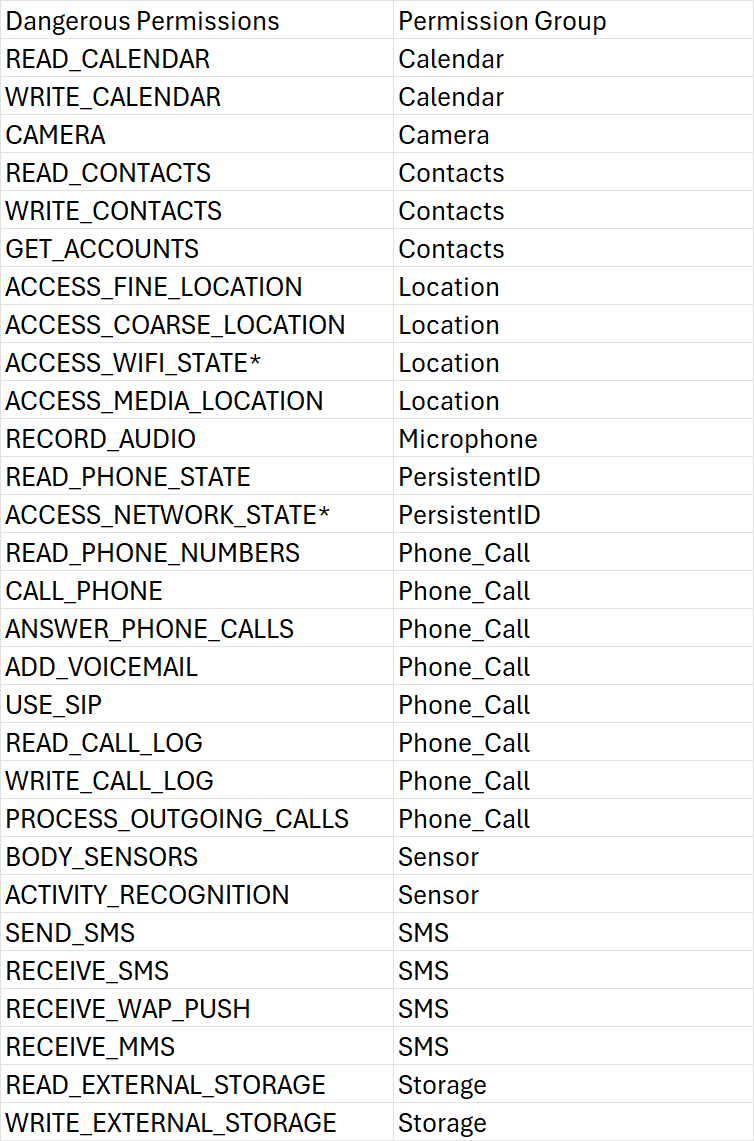

In [ ]:
# show the values of perm
perm_examples = defaultdict(set)

for entry in df_mpp['Perm']:
    if isinstance(entry, dict):
        for key, value in entry.items():
            # Convert list or other types to string safely
            if isinstance(value, list):
                joined = "; ".join(map(str, value))
                perm_examples[key].add(joined)
            else:
                perm_examples[key].add(str(value))

# Show output
for perm, descriptions in perm_examples.items():
    print(f"{perm.upper()}:")
    for desc in list(descriptions):
        print(f"  - {desc}")
    print()


WI-FI CONNECTION INFORMATION:
  - view Wi-Fi connections

OTHER:
  - access Bluetooth settings; allow Wi-Fi Multicast reception; change network connectivity; change system display settings; connect and disconnect from Wi-Fi; control flashlight; control vibration; draw over other apps; full network access; modify system settings; pair with Bluetooth devices; prevent device from sleeping; view network connections
  - full network access; measure app storage space; prevent device from sleeping; read Google service configuration; read sync settings; run at startup; toggle sync on and off; use accounts on the device; view network connections
  - control vibration; full network access; prevent device from sleeping; reorder running apps; view network connections
  - change network connectivity; change your audio settings; connect and disconnect from Wi-Fi; control Near Field Communication; control flashlight; control vibration; draw over other apps; full network access; install shortcuts; mea

In [ ]:
perm_map = {
    'location': 'LOCATION',
    'photos/media/files': 'STORAGE',
    'storage': 'STORAGE',
    'camera': 'CAMERA',
    'microphone': 'MICROPHONE',
    'device id & call information': 'PERSISTENTID',
    'cellular data settings': 'PERSISTENTID',
    'persistentid': 'PERSISTENTID',
    'sms': 'SMS',
    'calendar': 'CALENDAR',
    'contacts': 'CONTACTS',
    'identity': 'CONTACTS',
    'sensors': 'SENSOR',
    'wearable sensors/activity data': 'SENSOR',
    'wi-fi connection information': ['LOCATION', 'PERSISTENTID'],  # for ACCESS_WIFI_STATE, ACCESS_NETWORK_STATE
    'uncategorized': None,
    'other': None
}

def map_permissions_list(raw_perms):
    mapped_perms = []

    if not isinstance(raw_perms, dict):
        return mapped_perms

    for cat in raw_perms:
        cat_lower = cat.lower()

        # Special case for 'other' + 'view network connection'
        if cat_lower == 'other':
            # Check if 'view network connection' is in the values for this key
            perms_in_other = raw_perms[cat]
            if any('view network connection' in p.lower() for p in perms_in_other):
                if 'PERSISTENTID' not in mapped_perms:
                    mapped_perms.append('PERSISTENTID')
                continue

        # Special case for 'phone' key with detailed checks
        if cat_lower == 'phone':
            perms_in_phone = raw_perms[cat]
            for p in perms_in_phone:
                p_lower = p.lower()
                if 'phone status' in p_lower:
                    if 'PERSISTENTID' not in mapped_perms:
                        mapped_perms.append('PERSISTENTID')
                if 'phone number' in p_lower or 'call phone' in p_lower:
                    if 'PHONE_CALL' not in mapped_perms:
                        mapped_perms.append('PHONE_CALL')
            continue

        std_cat = perm_map.get(cat_lower)

        if isinstance(std_cat, list):
            for item in std_cat:
                if item not in mapped_perms:
                    mapped_perms.append(item)
        elif isinstance(std_cat, str):
            if std_cat not in mapped_perms:
                mapped_perms.append(std_cat)

    return mapped_perms


In [ ]:
# Change dict permissions fetched from google
df_mpp["Permissions_keyword"] = df_mpp['Perm'].progress_apply(map_permissions_list)

  0%|          | 0/270 [00:00<?, ?it/s]

### Evaluate Keyword column

Evaluate how well Permissions_keyword column (based on NLP from policies) aligns with the actual dangerous permissions declared in the manifest (those columns like CAMERA, LOCATION, where 1 or NOT FOUND = requested).

In [ ]:
df_mpp2 = df_mpp[df_mpp['Perm'] != "Not Available"].copy()

#Convert to sets
df_mpp2["Permissions Used"] = df_mpp2["Permissions Used"].apply(set)
df_mpp2["Permissions_keyword"] = df_mpp2["Permissions_keyword"].apply(set)


In [ ]:
#Compare Predicted vs. Actual
#Precision: How many of the keyword-predicted permissions are correct?
#Recall: How many of the actual dangerous permissions were detected?
#F1-score: Harmonic mean of precision and recall

def evaluate_prediction(row):
    predicted = row["Permissions_keyword"]
    actual = row["Permissions Used"]

    true_positives = predicted & actual
    precision = len(true_positives) / len(predicted) if predicted else 0
    recall = len(true_positives) / len(actual) if actual else 0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0

    return pd.Series([precision, recall, f1])

df_mpp2[["Precision", "Recall", "F1"]] = df_mpp2.apply(evaluate_prediction, axis=1)

print("Mean Precision:", df_mpp2["Precision"].mean())
print("Mean Recall:", df_mpp2["Recall"].mean())
print("Mean F1-score:", df_mpp2["F1"].mean())



Mean Precision: 0.9260598544973545
Mean Recall: 0.9248726851851852
Mean F1-score: 0.9131670843203352


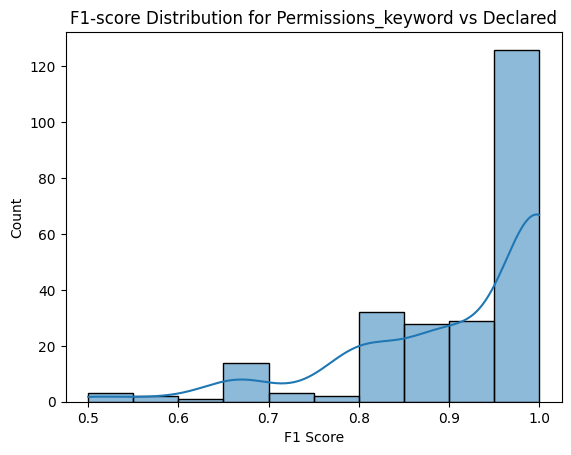

In [ ]:
# plot f1
sns.histplot(df_mpp2["F1"], bins=10, kde=True)
plt.title("F1-score Distribution for Permissions_keyword vs Declared")
plt.xlabel("F1 Score")
plt.show()


In [ ]:
#  Initialize and compute TP, FP, FN per permission
perm_stats = defaultdict(lambda: {"TP": 0, "FP": 0, "FN": 0})

for _, row in df_mpp2.iterrows():
    pred = row["Permissions_keyword"]
    actual = row["Permissions Used"]
    for perm in perm_label:
        if perm in pred and perm in actual:
            perm_stats[perm]["TP"] += 1
        elif perm in pred and perm not in actual:
            perm_stats[perm]["FP"] += 1
        elif perm not in pred and perm in actual:
            perm_stats[perm]["FN"] += 1

#  Build per-permission evaluation metrics
perm_eval_data = []

for perm, stats in perm_stats.items():
    TP = stats["TP"]
    FP = stats["FP"]
    FN = stats["FN"]
    precision = TP / (TP + FP) if TP + FP > 0 else 0
    recall = TP / (TP + FN) if TP + FN > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0

    perm_eval_data.append({
        "Permission": perm,
        "True Positives": TP,
        "False Positives": FP,
        "False Negatives": FN,
        "Support (Actual)": TP + FN,
        "Precision": round(precision, 2),
        "Recall": round(recall, 2),
        "F1 Score": round(f1, 2)
    })

perm_eval_df = pd.DataFrame(perm_eval_data).sort_values(by="F1 Score", ascending=False)

#  Calculate Macro Average
macro_precision = perm_eval_df["Precision"].mean()
macro_recall = perm_eval_df["Recall"].mean()
macro_f1 = perm_eval_df["F1 Score"].mean()

# Calculate Weighted Averages
total_support = perm_eval_df["Support (Actual)"].sum()

weighted_precision = (perm_eval_df["Precision"] * perm_eval_df["Support (Actual)"]).sum() / total_support
weighted_recall = (perm_eval_df["Recall"] * perm_eval_df["Support (Actual)"]).sum() / total_support
weighted_f1 = (perm_eval_df["F1 Score"] * perm_eval_df["Support (Actual)"]).sum() / total_support

macro_row = {
    "Permission": "Macro Average",
    "True Positives": "",
    "False Positives": "",
    "False Negatives": "",
    "Support (Actual)": "",
    "Precision": round(macro_precision, 2),
    "Recall": round(macro_recall, 2),
    "F1 Score": round(macro_f1, 2)
}

weighted_row = {
    "Permission": "Weighted Average",
    "True Positives": "",
    "False Positives": "",
    "False Negatives": "",
    "Support (Actual)": int(total_support),
    "Precision": round(weighted_precision, 2),
    "Recall": round(weighted_recall, 2),
    "F1 Score": round(weighted_f1, 2)
}

# Append Macro and Weighted rows
perm_eval_df = pd.concat([perm_eval_df, pd.DataFrame([macro_row, weighted_row])], ignore_index=True)

#  Display and save
perm_eval_df.to_excel("permission_evaluation_metrics.xlsx", index=False)
perm_eval_df


,Permission,True Positives,False Positives,False Negatives,Support (Actual),Precision,Recall,F1 Score
0,PERSISTENTID,240,0,0,240,1.00,1.00,1.00
1,LOCATION,201,9,9,210,0.96,0.96,0.96
2,STORAGE,172,7,21,193,0.96,0.89,0.92
3,CAMERA,96,16,3,99,0.86,0.97,0.91
4,MICROPHONE,79,21,5,84,0.79,0.94,0.86
5,CONTACTS,88,11,17,105,0.89,0.84,0.86
6,PHONE_CALL,22,4,5,27,0.85,0.81,0.83
7,SMS,10,4,2,12,0.71,0.83,0.77
8,CALENDAR,18,9,5,23,0.67,0.78,0.72
9,SENSOR,2,2,7,9,0.50,0.22,0.31


The old permission labels are from 2021, based on Android manifests and testing tools. The current permissions are scraped from Google Play and show the latest app permission requests.

Apps change permissions over time. For example, Xender may have requested SMS or Phone Call permissions in 2021 but not anymore. This causes false negatives when comparing current permissions to old labels.
Similarly where new access is requested it causes false positives.

So, false negatives and false positives mostly come from permission changes over time, not from errors in scraping or mapping. This also affects recall and F1 scores, especially for less common permissions.



*   False negatives occur when an app used to request a permission in 2021 but no longer does now (so  current scraping “misses” it compared to old labels).

*   False positives happen when an app now requests a permission that it did not request in 2021 ( scraping shows it, but old labels don’t), appearing as “errors” but actually reflecting real changes.

**Metric Interpretation**
-  **Macro Average F1 (0.81)** treats each permission equally regardless of how often it appears. This score reflects balanced performance across both common and rare permissions. The lower score for less frequent permissions, like SENSOR (F1 = 0.31), reflects difficulties due to limited data and changes over time.

-  **Weighted Average F1 (0.92)** accounts for the number of samples per permission, emphasizing the model’s performance on frequently requested permissions such as PERSISTENTID, LOCATION, STORAGE, and CAMERA, where F1 scores are very high (0.91 to 1.00).

**Note:** Micro accuracy was not included because true negatives are undefined in this context, given the nature of permission presence/absence comparisons.

In [ ]:
df_mpp2.to_excel('df_mpp2.xlsx', index=False)